# 1 Ingesta de datos desde mysql

In [4]:
!python --version

Python 3.8.20


In [5]:
from pyspark.sql import SparkSession

In [6]:
spark = SparkSession.builder\
    .master("spark://spark-master:7077")\
    .appName("Ingesta")\
    .config("spark.jars", "/opt/spark/jars/mysql-connector-j-8.4.0.jar")\
    .getOrCreate()    

In [7]:
import pyspark
import os

print("PySpark:", pyspark.__version__)
print("Spark:", spark.version)

PySpark: 3.5.1
Spark: 3.5.1


In [8]:
!ls /opt/spark/jars/mysql-connector-j-8.4.0.jar

/opt/spark/jars/mysql-connector-j-8.4.0.jar


In [10]:
df_categories = (spark.read
         .format("jdbc")
         .option("url", "jdbc:mysql://mysql:3306/retail_db")
         .option("dbtable", "categories")
         .option("user", "root")
         .option("password", "root")
         .option("driver", "com.mysql.cj.jdbc.Driver")
         .load())
df_categories.show()

+-----------+----------------------+-------------------+
|category_id|category_department_id|      category_name|
+-----------+----------------------+-------------------+
|          1|                     2|           Football|
|          2|                     2|             Soccer|
|          3|                     2|Baseball & Softball|
|          4|                     2|         Basketball|
|          5|                     2|           Lacrosse|
|          6|                     2|   Tennis & Racquet|
|          7|                     2|             Hockey|
|          8|                     2|        More Sports|
|          9|                     3|   Cardio Equipment|
|         10|                     3|  Strength Training|
|         11|                     3|Fitness Accessories|
|         12|                     3|       Boxing & MMA|
|         13|                     3|        Electronics|
|         14|                     3|     Yoga & Pilates|
|         15|                  

In [11]:
print("Particiones:", df_categories.rdd.getNumPartitions())

Particiones: 1


# Reto de clase
#### 1 realizar un procesamiento de join

#### 2 realizar iun procesamiento de agrupacion

#### 3 escribirlo a una capa cleansed 

#### 4 escribir sobre la misma base retail_db con el nombre de tabla cleansed_agregado

In [12]:
df_productos = (spark.read
         .format("jdbc")
         .option("url", "jdbc:mysql://mysql:3306/retail_db")
         .option("dbtable", "products")
         .option("user", "root")
         .option("password", "root")
         .option("driver", "com.mysql.cj.jdbc.Driver")
         .load())
df_productos.show()

+----------+-------------------+--------------------+-------------------+-------------+--------------------+
|product_id|product_category_id|        product_name|product_description|product_price|       product_image|
+----------+-------------------+--------------------+-------------------+-------------+--------------------+
|         1|                  2|Quest Q64 10 FT. ...|                   |        59.98|http://images.acm...|
|         2|                  2|Under Armour Men'...|                   |       129.99|http://images.acm...|
|         3|                  2|Under Armour Men'...|                   |        89.99|http://images.acm...|
|         4|                  2|Under Armour Men'...|                   |        89.99|http://images.acm...|
|         5|                  2|Riddell Youth Rev...|                   |       199.99|http://images.acm...|
|         6|                  2|Jordan Men's VI R...|                   |       134.99|http://images.acm...|
|         7|       

# 2 SPARK SQL

In [12]:
df_categories.createOrReplaceTempView("categorias")
df_productos.createOrReplaceTempView("productos")

In [13]:
df_conjuncion = spark.sql("""
    SELECT
        c.category_id,
        c.category_name,
        p.product_id,
        p.product_name,
        p.product_category_id
    FROM categorias c
    INNER JOIN productos p
    ON c.category_id = p.product_category_id
""")

df_conjuncion.printSchema()
df_conjuncion.show()

root
 |-- category_id: integer (nullable = true)
 |-- category_name: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- product_category_id: integer (nullable = true)



+-----------+------------------+----------+--------------------+-------------------+
|category_id|     category_name|product_id|        product_name|product_category_id|
+-----------+------------------+----------+--------------------+-------------------+
|         31|Women's Golf Clubs|       669|Cleveland Golf My...|                 31|
|         31|Women's Golf Clubs|       670|Cleveland Golf El...|                 31|
|         31|Women's Golf Clubs|       671|Cleveland Golf Co...|                 31|
|         31|Women's Golf Clubs|       672|     PING G30 Driver|                 31|
|         31|Women's Golf Clubs|       673|PING G30 Fairway ...|                 31|
|         31|Women's Golf Clubs|       674|     PING G30 Hybrid|                 31|
|         31|Women's Golf Clubs|       675|PING G30 Irons - ...|                 31|
|         31|Women's Golf Clubs|       676|PING G30 Irons - ...|                 31|
|         31|Women's Golf Clubs|       677|TaylorMade White ...| 

In [14]:
df_top_cantidades = spark.sql("""
   SELECT
    product_category_id,
    SUM(product_id) AS total_product_id
    FROM productos
    GROUP BY product_category_id
    ORDER BY total_product_id DESC
    LIMIT 4;
""")

df_top_cantidades.printSchema()
df_top_cantidades.show()

root
 |-- product_category_id: integer (nullable = true)
 |-- total_product_id: long (nullable = true)



[Stage 10:>                                                         (0 + 1) / 1]

+-------------------+----------------+
|product_category_id|total_product_id|
+-------------------+----------------+
|                 41|           36696|
|                 59|           32004|
|                 58|           31428|
|                 57|           30852|
+-------------------+----------------+



# 3  Particiones

In [13]:
df_productos_particionado = (spark.read
       .format("jdbc")
       .option("url", "jdbc:mysql://mysql:3306/retail_db")
       .option("dbtable", "products")
       .option("user", "root")
       .option("password", "root")
       .option("driver", "com.mysql.cj.jdbc.Driver")
       .option("partitionColumn", "product_id")
       .option("lowerBound", "1")
       .option("upperBound", "100000")
       .option("numPartitions", "4")
       .load())

In [14]:
print("Particiones:", df_productos_particionado.rdd.getNumPartitions())
print("Paralelismo:", spark.sparkContext.defaultParallelism)

Particiones: 4
Paralelismo: 4


In [17]:
df_categorias_particionado = (spark.read
       .format("jdbc")
       .option("url", "jdbc:mysql://mysql:3306/retail_db")
       .option("dbtable", "categories")
       .option("user", "root")
       .option("password", "root")
       .option("driver", "com.mysql.cj.jdbc.Driver")
       .option("partitionColumn", "category_id")
       .option("lowerBound", "1")
       .option("upperBound", "100000")
       .option("numPartitions", "9")
       .load())

In [18]:
df_categorias_particionado.count()

58

In [19]:
print("Particiones:", df_categorias_particionado.rdd.getNumPartitions())
print("Paralelismo:", spark.sparkContext.defaultParallelism)

Particiones: 9
Paralelismo: 2


In [20]:
   # SELECT
   #  product_category_id,
   #  SUM(product_id) AS total_product_id
   #  FROM productos
   #  GROUP BY product_category_id
   #  ORDER BY total_product_id DESC
   #  LIMIT 4;
from pyspark.sql.functions import sum, col

df_productos_particionado.groupBy("product_category_id") \
   .agg(sum("product_id").alias("total_product_id")) \
   .orderBy(col('total_product_id').desc())\
   .show(4)

[Stage 14:=============================>                            (2 + 2) / 4]

+-------------------+----------------+
|product_category_id|total_product_id|
+-------------------+----------------+
|                 41|           36696|
|                 59|           32004|
|                 58|           31428|
|                 57|           30852|
+-------------------+----------------+
only showing top 4 rows



In [21]:
df_conjuncion_particionado=df_categorias_particionado.join(df_productos_particionado,\
                                                           df_categorias_particionado.category_id==df_productos_particionado.product_category_id,'inner')

In [22]:
df_conjuncion_particionado.printSchema()

root
 |-- category_id: integer (nullable = true)
 |-- category_department_id: integer (nullable = true)
 |-- category_name: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- product_category_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- product_description: string (nullable = true)
 |-- product_price: double (nullable = true)
 |-- product_image: string (nullable = true)



In [23]:
# Cantidad de productos por categoría
from pyspark.sql.functions import count, col
df_agregada=df_conjuncion_particionado \
    .groupBy("category_id", "category_name") \
    .agg(count("product_id").alias("cantidad_productos")) \
    .orderBy(col("cantidad_productos").desc()) \
    .limit(5)
df_agregada.count()

5

In [24]:
df_agregada.show()

+-----------+------------------+------------------+
|category_id|     category_name|cantidad_productos|
+-----------+------------------+------------------+
|         41|          Trade-In|                48|
|         38|  Kids' Golf Clubs|                48|
|         31|Women's Golf Clubs|                24|
|         53|              NCAA|                24|
|         34| Golf Bags & Carts|                24|
+-----------+------------------+------------------+



In [25]:
print("Particiones:", df_conjuncion_particionado.rdd.getNumPartitions())
print("Particiones:", df_agregada.rdd.getNumPartitions())
print("Paralelismo:", spark.sparkContext.defaultParallelism)

Particiones: 1


[Stage 34:==============>                                           (1 + 2) / 4]

Particiones: 1
Paralelismo: 2


In [26]:
df_agregada.write.mode("overwrite").csv("hdfs://namenode:8020/datalake/raw/categories_agregado_2",header='true')

In [27]:
df_agregada_read = spark.read \
   .option("header", "true") \
   .option("inferSchema", "true") \
   .csv("hdfs://namenode:8020/datalake/raw/categories_agregado_2")

In [28]:
df_agregada_read.show()

+-----------+------------------+------------------+
|category_id|     category_name|cantidad_productos|
+-----------+------------------+------------------+
|         41|          Trade-In|                48|
|         38|  Kids' Golf Clubs|                48|
|         31|Women's Golf Clubs|                24|
|         53|              NCAA|                24|
|         34| Golf Bags & Carts|                24|
+-----------+------------------+------------------+



In [29]:
df_agregada_read.write \
    .format("jdbc") \
    .mode("overwrite") \
    .option("url", "jdbc:mysql://mysql:3306/retail_db") \
    .option("dbtable", "categories_agregado_2") \
    .option("user", "root") \
    .option("password", "root") \
    .option("driver", "com.mysql.cj.jdbc.Driver") \
    .save()

In [30]:
print("Particiones:", df_agregada_read.rdd.getNumPartitions())
print("Paralelismo Spark:", spark.sparkContext.defaultParallelism)

Particiones: 1
Paralelismo Spark: 2


In [31]:
df_agregada_read_paralelo=df_agregada_read.repartition(8)

In [32]:
print("Particiones:", df_agregada_read_paralelo.rdd.getNumPartitions())
print("Paralelismo Spark:", spark.sparkContext.defaultParallelism)

Particiones: 8
Paralelismo Spark: 2


In [33]:
(df_agregada_read_paralelo.write
    .format("jdbc")
    .mode("overwrite")
    .option("url", "jdbc:mysql://mysql:3306/retail_db")
    .option("dbtable", "categories_agregado")
    .option("user", "root")
    .option("password", "root")
    .option("driver", "com.mysql.cj.jdbc.Driver")
    .option("batchsize", "1000")
    .save())

In [34]:
df_agregada_read_paralelo.write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("hdfs://namenode:8020/datalake/raw/categories_agregado")

In [35]:
!java -version

openjdk version "17.0.20" 2026-07-21
OpenJDK Runtime Environment (build 17.0.20+8-1-deb12u1-Debian)
OpenJDK 64-Bit Server VM (build 17.0.20+8-1-deb12u1-Debian, mixed mode, sharing)


# Interfaces y monitoreo

In [36]:
spark.sparkContext.uiWebUrl

'http://jupyter:4040'

In [37]:
sc = spark.sparkContext

print("App:", sc.appName)
print("Master:", sc.master)
print("Default parallelism:", sc.defaultParallelism)

App: Ingesta
Master: spark://spark-master:7077
Default parallelism: 2


In [38]:
spark.sparkContext._jsc.sc().getExecutorIds()

JavaObject id=o171

In [39]:
rdd = spark.sparkContext.parallelize(range(1,10000000), 20)
rdd.map(lambda x: x*x).count()

9999999

In [40]:
df = (spark.range(0,10000000).withColumnRenamed("id","id_cliente"))
df.show()

+----------+
|id_cliente|
+----------+
|         0|
|         1|
|         2|
|         3|
|         4|
|         5|
|         6|
|         7|
|         8|
|         9|
|        10|
|        11|
|        12|
|        13|
|        14|
|        15|
|        16|
|        17|
|        18|
|        19|
+----------+
only showing top 20 rows



In [41]:
df.rdd.getNumPartitions()

2

Dataset

2 particiones

↓

2 tareas potenciales

In [44]:
df2 = df.repartition(20)

In [45]:
from pyspark.sql.functions import spark_partition_id
(df2.withColumn("particion",spark_partition_id())
.groupBy("particion")
.count()
.show())

[Stage 61:===============================================>        (17 + 2) / 20]

+---------+------+
|particion| count|
+---------+------+
|        0|500000|
|        1|500000|
|        2|500000|
|        3|500000|
|        4|500000|
|        5|500000|
|        6|500000|
|        7|500000|
|        8|500000|
|        9|500000|
|       10|500000|
|       11|500000|
|       12|500000|
|       13|500000|
|       14|500000|
|       15|500000|
|       16|500000|
|       17|500000|
|       18|500000|
|       19|500000|
+---------+------+



20 particiones

↓

20 tareas

In [15]:
df_categorias_particionado = (spark.read
       .format("jdbc")
       .option("url", "jdbc:mysql://mysql:3306/retail_db")
       .option("dbtable", "categories")
       .option("user", "root")
       .option("password", "root")
       .option("driver", "com.mysql.cj.jdbc.Driver")
       .option("partitionColumn", "category_id")
       .option("lowerBound", "1")
       .option("upperBound", "100000")
       .option("numPartitions", "5")
       .load())

In [16]:
df_categorias_particionado.count()

58

In [45]:
!python --version

Python 3.10.20


In [36]:
print(spark.sparkContext.uiWebUrl)

http://jupyter:4040


# Practica 3

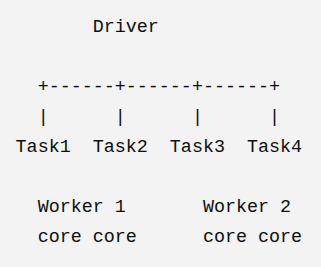

In [60]:
from pyspark.sql.functions import rand, col
df = (spark.range(0,5000000).withColumn("valor", rand()*1000))
print("Particiones iniciales:", df.rdd.getNumPartitions())

Particiones iniciales: 4


In [61]:
from pyspark.sql.functions import expr
df_proceso = (df.withColumn("calculo", expr("""
        sqrt(valor)
        """)))

In [ ]:
print("Particiones:",p)
    inicio=time.time()
    (
      df_test
      .withColumn("calculo", col("id")*10)
      .groupBy()
      .sum("calculo")
      .show()
    )
    print("Tiempo:",time.time()-inicio)

In [62]:
for p in [1,2,4,8,16]:
    df_test = df_proceso.repartition(p)
    print("Particiones:",p)
    inicio=time.time()
    (
      df_test
      .withColumn("calculo", col("id")*10)
      .groupBy()
      .sum("calculo")
      .show()
    )
    print("Tiempo:",time.time()-inicio)

Particiones: 1


+---------------+
|   sum(calculo)|
+---------------+
|124999975000000|
+---------------+

Tiempo: 2.5887672901153564
Particiones: 2


+---------------+
|   sum(calculo)|
+---------------+
|124999975000000|
+---------------+

Tiempo: 6.387414932250977
Particiones: 4


+---------------+
|   sum(calculo)|
+---------------+
|124999975000000|
+---------------+

Tiempo: 5.941762208938599
Particiones: 8


+---------------+
|   sum(calculo)|
+---------------+
|124999975000000|
+---------------+

Tiempo: 5.4129884243011475
Particiones: 16


[Stage 117:================================================>      (14 + 2) / 16]

+---------------+
|   sum(calculo)|
+---------------+
|124999975000000|
+---------------+

Tiempo: 5.836468935012817


# Conclusion
repartition(1) → lento

repartition(4) → más rápido

repartition(16) → vuelve a empeorar


## Conclusión:

- "El paralelismo mejora cuando el número de particiones está alineado con los recursos disponibles"
- "Excederse genera costo de coordinación."